## Item-Based Collaborative Filtering (KNN With Means)
**Dataset:** CiaoDVD  
**Library:** Surprise (scikit-surprise)  

---
## 1. Imports & Setup

In [1]:
!pip install scikit-surprise
!pip install "numpy<2"

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from surprise import Dataset, Reader, KNNWithMeans, accuracy
from surprise.model_selection import train_test_split, GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load & Preprocess CiaoDVD Data

The CiaoDVD `movie-ratings.txt` file contains:  
`user_id | movie_id | category_id | review_id | rating | date`  
We keep only `user_id`, `movie_id`, and `rating`.

In [3]:
import os
import urllib.request
import zipfile

# ── Locate the ratings file (handles both local and Colab/repo layouts) ────────
CANDIDATE_PATHS = [
    '../data/movie-ratings.txt',
    '../data/CiaoDVD/movie-ratings.txt',
    'data/movie-ratings.txt',
    'movie-ratings.txt',
]

DATA_PATH = None
# We'll skip the local check if we just downloaded the zip incorrectly
if not os.path.exists('CiaoDVD.zip') and not os.path.exists('CiaoDVD/movie-ratings.txt'):
    for p in CANDIDATE_PATHS:
        if os.path.exists(p) and not p == 'movie-ratings.txt': # Avoid using the broken zip file
            DATA_PATH = p
            break

if DATA_PATH is None:
    print('Dataset not found or needs extraction. Downloading...')
    DATA_URL = 'https://guoguibing.github.io/librec/datasets/CiaoDVD.zip'
    try:
        # Download the zip file
        urllib.request.urlretrieve(DATA_URL, 'CiaoDVD.zip')
        print('Download complete. Extracting...')

        # Extract the zip file
        with zipfile.ZipFile('CiaoDVD.zip', 'r') as zip_ref:
            zip_ref.extractall('CiaoDVD_extracted')

        # The dataset inside the zip should contain the file
        DATA_PATH = 'CiaoDVD_extracted/movie-ratings.txt'
        print('Extraction complete.')
    except Exception as e:
        raise FileNotFoundError(
            f"Failed to download or extract the dataset. Error: {e}"
        )

print(f'Using dataset: {DATA_PATH}')

Dataset not found or needs extraction. Downloading...
Download complete. Extracting...
Extraction complete.
Using dataset: CiaoDVD_extracted/movie-ratings.txt


In [4]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw_df = pd.read_csv(
    DATA_PATH,
    sep=',',
    header=None,
    names=['user_id', 'movie_id', 'category_id', 'review_id', 'rating', 'date'],
    engine='python'
)

print(f'Raw shape: {raw_df.shape}')
raw_df.head()

Raw shape: (72665, 6)


,user_id,movie_id,category_id,review_id,rating,date
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [5]:
# ── Preprocessing ──────────────────────────────────────────────────────────────
df = raw_df[['user_id', 'movie_id', 'rating']].copy()

# 1) Drop missing values
df.dropna(inplace=True)

# 2) Keep only valid ratings (CiaoDVD uses 1–5 scale)
RATING_MIN, RATING_MAX = 1, 5
df = df[(df['rating'] >= RATING_MIN) & (df['rating'] <= RATING_MAX)]

# 3) Remove duplicate (user, item) pairs — keep the most recent (last) entry
df.drop_duplicates(subset=['user_id', 'movie_id'], keep='last', inplace=True)

# 4) Cold-start filter: keep users with ≥5 ratings & items with ≥5 ratings
user_counts = df['user_id'].value_counts()
item_counts = df['movie_id'].value_counts()
df = df[
    df['user_id'].isin(user_counts[user_counts >= 5].index) &
    df['movie_id'].isin(item_counts[item_counts >= 5].index)
]

df.reset_index(drop=True, inplace=True)

print(f'Cleaned shape : {df.shape}')
print(f'Unique users  : {df["user_id"].nunique():,}')
print(f'Unique movies : {df["movie_id"].nunique():,}')
print(f'Rating range  : [{df["rating"].min()} – {df["rating"].max()}]')
print(f'Avg rating    : {df["rating"].mean():.3f}')

sparsity = 1 - len(df) / (df['user_id'].nunique() * df['movie_id'].nunique())
print(f'Matrix sparsity: {sparsity:.4%}')

Cleaned shape : (33607, 3)
Unique users  : 2,567
Unique movies : 3,063
Rating range  : [1 – 5]
Avg rating    : 4.043
Matrix sparsity: 99.5726%


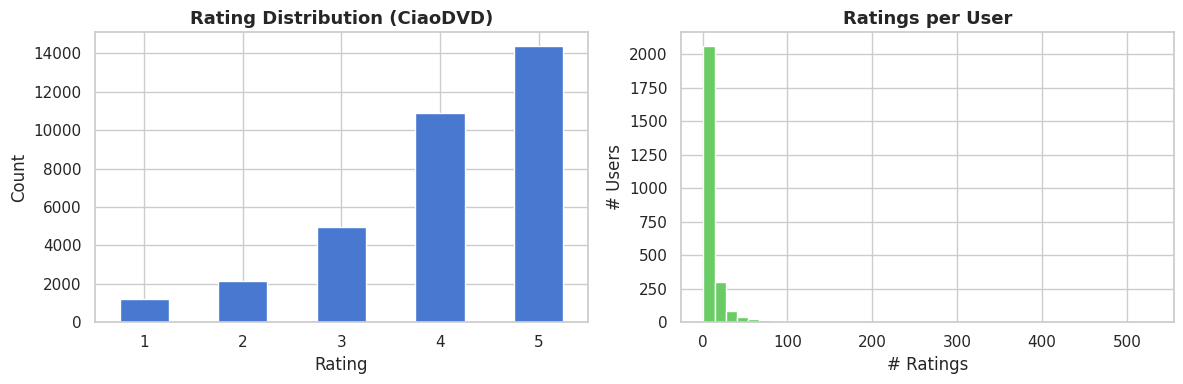

In [6]:
# ── Rating distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('muted')[0], edgecolor='white'
)
axes[0].set_title('Rating Distribution (CiaoDVD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['user_id'].value_counts().pipe(
    lambda s: axes[1].hist(s, bins=40, color=sns.color_palette('muted')[2], edgecolor='white')
)
axes[1].set_title('Ratings per User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# Ratings')
axes[1].set_ylabel('# Users')

plt.tight_layout()
os.makedirs('./results/figures', exist_ok=True)
plt.savefig('./results/figures/03_item_cf_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Build Surprise Dataset & Train/Test Split (80/20)

In [7]:
reader  = Reader(rating_scale=(RATING_MIN, RATING_MAX))
dataset = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# 80/20 split with fixed random state for reproducibility
trainset, testset = train_test_split(dataset, test_size=0.20, random_state=42)

print(f'Training ratings : {trainset.n_ratings:,}')
print(f'Test ratings     : {len(testset):,}')

Training ratings : 26,885
Test ratings     : 6,722


---
## 4. Hyperparameter Tuning via GridSearchCV (5-Fold CV)

**KNNWithMeans** subtracts each item's mean rating before computing similarity, which corrects for items that are systematically rated higher or lower than average.

Setting `user_based=False` inside `sim_options` tells Surprise to compute **item-item** similarity (columns of the user-item matrix) rather than user-user similarity.

In [8]:
param_grid = {
    'k':     [10, 20, 40],       # neighbourhood size
    'min_k': [1, 3],             # minimum neighbours required for prediction
    'sim_options': {
        'name': ['cosine', 'pearson', 'msd'],  # similarity metrics
        'user_based': [False]                  # item-based
    }
}

print('Running GridSearchCV for Item-Based KNN (this may take a few minutes)…')
gs = GridSearchCV(
    KNNWithMeans,
    param_grid,
    measures=['rmse', 'mae'],
    cv=5,
    refit=True,
    n_jobs=-1,
    joblib_verbose=0
)
gs.fit(dataset)

print('\n── Best params (by RMSE) ──')
print(gs.best_params['rmse'])
print(f'\nBest CV RMSE : {gs.best_score["rmse"]:.4f}')
print(f'Best CV MAE  : {gs.best_score["mae"]:.4f}')


Running GridSearchCV for Item-Based KNN (this may take a few minutes)…
Computing the cosine similarity matrix...
Done computing similarity matrix.

── Best params (by RMSE) ──
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'cosine', 'user_based': False}}

Best CV RMSE : 0.9516
Best CV MAE  : 0.7121


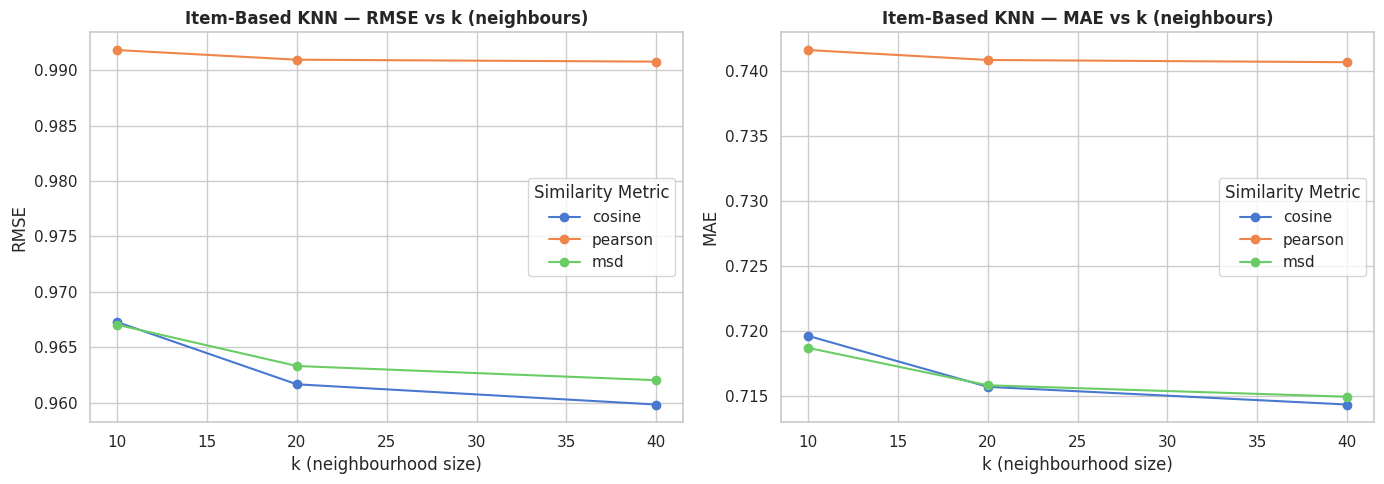

Figure saved → ./results/figures/03_item_cf_cv_results.png


In [9]:
# ── Visualise CV results ──────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results)
cv_results['sim_name'] = cv_results['param_sim_options'].apply(lambda x: x['name'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (metric, label) in enumerate([('mean_test_rmse', 'RMSE'), ('mean_test_mae', 'MAE')]):
    for sim in ['cosine', 'pearson', 'msd']:
        sub   = cv_results[cv_results['sim_name'] == sim]
        pivot = sub.groupby('param_k')[metric].mean()
        axes[i].plot(pivot.index, pivot.values, marker='o', label=sim)
    axes[i].set_title(f'Item-Based KNN — {label} vs k (neighbours)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('k (neighbourhood size)')
    axes[i].set_ylabel(label)
    axes[i].legend(title='Similarity Metric')

plt.tight_layout()
plt.savefig('./results/figures/03_item_cf_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → ./results/figures/03_item_cf_cv_results.png')

---
## 5. Final Evaluation on the Test Set

In [10]:
best_model = gs.best_estimator['rmse']
best_model.fit(trainset)
predictions = best_model.test(testset)

rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions,  verbose=False)

print('══════════════════════════════════════════════')
print('  Item-Based CF (KNNWithMeans) — Test Results')
print('══════════════════════════════════════════════')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print('══════════════════════════════════════════════')
bp = gs.best_params['rmse']
print(f"\n  Best params →  k={bp['k']}  |  min_k={bp['min_k']}  |  sim={bp['sim_options']['name']}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
══════════════════════════════════════════════
  Item-Based CF (KNNWithMeans) — Test Results
══════════════════════════════════════════════
  RMSE : 0.9418
  MAE  : 0.7090
══════════════════════════════════════════════

  Best params →  k=40  |  min_k=3  |  sim=cosine


---
## 6. Error Analysis — Prediction Residuals

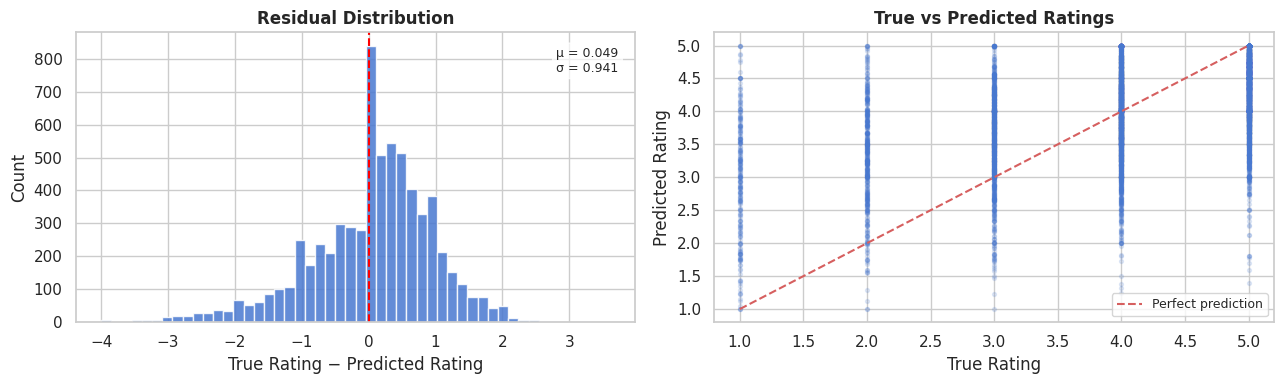

Figure saved → ./results/figures/03_item_cf_error_analysis.png


In [11]:
true_r    = np.array([p.r_ui for p in predictions])
est_r     = np.array([p.est  for p in predictions])
residuals = true_r - est_r

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette   = sns.color_palette('muted')

# Residual histogram
axes[0].hist(residuals, bins=50, color=palette[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('True Rating − Predicted Rating')
axes[0].set_ylabel('Count')
stats_txt = f'μ = {np.mean(residuals):.3f}\nσ = {np.std(residuals):.3f}'
axes[0].text(0.97, 0.95, stats_txt, transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# True vs Predicted scatter
axes[1].scatter(true_r, est_r, alpha=0.15, s=8, color=palette[0])
axes[1].plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('True vs Predicted Ratings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('True Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('./results/figures/03_item_cf_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → ./results/figures/03_item_cf_error_analysis.png')

---
## 7. Save Results

In [12]:
bp = gs.best_params['rmse']

results_df = pd.DataFrame([{
    'Algorithm':   'Item-Based CF (KNNWithMeans)',
    'RMSE':        round(rmse, 4),
    'MAE':         round(mae, 4),
    'k':           bp['k'],
    'min_k':       bp['min_k'],
    'similarity':  bp['sim_options']['name'],
    'CV_folds':    5,
    'train_ratio': 0.80,
}])

results_df.to_csv('./results/03_item_cf_results.csv', index=False)
print('Results saved → ./results/03_item_cf_results.csv')
results_df

Results saved → ./results/03_item_cf_results.csv


,Algorithm,RMSE,MAE,k,min_k,similarity,CV_folds,train_ratio
0,Item-Based CF (KNNWithMeans),0.9418,0.709,40,3,cosine,5,0.8


---
## 8. Summary

### How Item-Based CF Works
Instead of finding similar **users** (as in Algorithm 2), Item-Based CF finds similar **items** by comparing the columns of the user-item rating matrix. To predict a user's rating for a target item, it takes a weighted average of that user's ratings for the most similar neighbouring items.

**KNNWithMeans** subtracts each item's mean rating before computing similarity, correcting for items that are globally rated higher or lower than average — a key improvement over basic KNN.

### Why Item-Based CF Often Outperforms User-Based CF
- Items tend to have **more ratings per entity** than users, making similarity estimates more reliable in sparse datasets.
- Item neighbourhoods are **more stable over time** — a movie doesn't change its genre, but a user's taste may drift.

### Preprocessing Decisions
| Step | Rationale |
|------|-----------|
| Drop NaNs & out-of-range ratings | Remove corrupted entries |
| Deduplicate `(user, item)` pairs | Prevent data leakage across splits |
| Cold-start filter (≥ 5 ratings) | KNN similarity requires a minimum number of co-rated items |
| 80/20 split (`random_state=42`) | Reproducible; consistent across all project notebooks |